이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- torchvision
- numpy
- matplotlib
- PIL
- kagglehub
- requests
- timm

- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 8-4 진짜 VGGNet과 ResNet 활용해 보기

본 노트북은 본문 8-4절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- timm 라이브러리로 허깅페이스 허브의 사전 학습 VGG-16 모델을 내려받아 이미지 분류에 사용
- 캐글의 흉부 X선 사진 데이터를 `ImageFolder`로 데이터셋과 데이터로더로 구성
- 사전 학습된 ResNet-50의 분류기 계층을 교체해 특징 추출 방식으로 전이 학습

본문의 모델 11의 구현에 해당되며, 모델 11의 제시문은 다음과 같다.

> **모델 11. 흉부 X선 사진 판독기**
>
> 흉부 X선 사진을 보고 정상과 비정상으로 분류하는 모델을 만들어 본다. ResNet-50 모델을 캐글의 흉부 X선 이미지 데이터로 추가 학습한다.

## timm으로 사전 학습 모델 사용

- `timm.create_model()`로 사전 학습된 모델을 내려받는다. 모델의 참조 이름은 timm 라이브러리 문서를 참조한다.
- 모델을 사용하는 데 필요한 데이터 변환 객체는 `timm.data.resolve_data_config()`와 `timm.data.create_transform()`으로 만들 수 있다.
    - timm이 단순히 모델만 제공하지 않고 활용에 필요한 여러 기능도 함께 제공한다는 것을 보여 주는 대목이다.
- `torch.topk()` 함수는 `torch.argmax()`와 달리 상위 k개의 로짓과 인덱스를 반환한다.

> 허깅페이스의 라이브러리로 모델이나 데이터셋을 내려받을 때 별도의 인증이 필요한 경우가 있다. 또한 timm 0.9 버전 이후로는 `pretrained=True` 인자의 동작 방식이 일부 변경될 수 있다. 코드가 잘 동작하지 않으면 사용 중인 timm 라이브러리 버전과 공식 문서를 함께 확인하자.

In [2]:
# 참고 - 테스트 이미지 경로
data_root = '../../data'

In [3]:
######################################################################################
# 코드 8-7 - timm 라이브러리를 통한 VGG-16 모델의 사용
######################################################################################

import torch
import timm
import requests
from PIL import Image

# 테스트 이미지로 깃허브의 data/cat.jpg를 사용(data_root는 data 디렉터리를 가리킴)
img = Image.open(data_root + '/cat.jpg') # Pillow 객체

# timm.create_model()을 사용해 파이토치 모델을 생성
# 모델의 참조 이름(vgg16_bn)은 timm 라이브러리 문서 참조
vggnet_16 = timm.create_model('vgg16_bn', pretrained=True).to(device)

# 모델 설정으로부터 데이터 변환 객체 만들기(Pillow 객체 -> 샘플 텐서 변환)
# ①모델 설정(vggnet_16.default_cfg)에서 모델의 데이터 설정 정보 추출
config = vggnet_16.default_cfg
transform_config = timm.data.resolve_data_config(config)

# ②데이터 설정 정보(transform_config)를 사용해 데이터 변환 객체 생성
# 딕셔너리를 언패킹 연산자(**)와 함께 인자로 지정 -> 키=값 형태 키워드 인자
transform = timm.data.create_transform(**transform_config)

# 이미지의 분류 결과 예측
# 합성곱 신경망 계층 입력을 위해 배치 차원 추가
input_tensor = transform(img).unsqueeze(0).to(device)
vggnet_16.eval()
with torch.no_grad():
    output = vggnet_16(input_tensor)
# 점수 기준 상위 5개 클래스를 선택(topk() 함수)
_, top5_idx = torch.topk(output, 5)

# top5_idx는 클래스의 인덱스 값이며, 이 값이 실제 무엇인지는 별도 정보가 필요
# VGGNet을 학습하는 데 사용한 ImageNet 데이터셋의 레이블 정보를 가져와 사용
url = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'
labels = requests.get(url).text.splitlines()

for i in range(5):
    label_name = labels[top5_idx[0, i].item()]
    print(f'{i + 1}위: {label_name}')

/home/crapas/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1위: tiger cat
2위: Egyptian cat
3위: tabby
4위: lynx
5위: tiger


## 흉부 X선 사진 데이터 준비

- 캐글의 데이터셋도 허깅페이스 허브의 모델처럼 미리 내려받아 두지 않고 `kagglehub.dataset_download()` 함수로 실행 시점에 내려받아 사용할 수 있다.
    - 압축을 풀기 전의 파일 크기가 2.3GB나 되므로 실습 전 디스크 공간이 충분한지 확인해야 한다.
- 내려받으면 용도별로 `train`, `val`, `test` 디렉터리가 생긴다.
    - 각 디렉터리는 다시 `NORMAL`(정상)과 `PNEUMONIA`(폐렴) 하위 디렉터리로 나뉘고 그 안에 이미지 파일이 들어 있다. 디렉터리 이름이 레이블의 역할을 한다.

In [4]:
# 참고 - kagglehub에서 흉부 X선 데이터셋 내려받기
from pathlib import Path
import kagglehub

download_dir = '../../download/'
xray_root = download_dir + 'kaggle/chest_xray/'
print('kagglehub로 chest-xray-pneumonia 데이터셋 다운로드 시도...')
# 약 2.3G의 데이터를 내려 받고, 압축 해제 과정을 거치므로 약 5G 정도의 디스크가 필요
# 미리 디스크 용량을 확인하고 진행하며, 실습 시점에 따라 데이터 사용 여부가 달라질 수 있음
path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia', output_dir=xray_root)

# 내려받은 후 train 디렉터리가 있는 경로를 확인
candidate = Path(path) / 'chest_xray'
xray_root = candidate if candidate.exists() else Path(path)
if (xray_root / 'train').exists():
    print(f'데이터셋 루트: {xray_root}')
else:
    print('데이터셋 루트에 train 디렉터리가 없습니다. 다운로드 실패 여부를 확인하세요.')

kagglehub로 chest-xray-pneumonia 데이터셋 다운로드 시도...


데이터셋 루트: ../../download/kaggle/chest_xray/chest_xray


- 클래스마다 나뉜 파일은 `torchvision` 라이브러리의 `ImageFolder` 클래스로 데이터셋을 만들 수 있다.
    - 디렉터리 경로(`root`)와 데이터 변환 객체(`transform`)를 인자로 받는다.
    - 클래스 레이블은 자동으로 0부터 차례로 매겨지며, `classes` 속성으로 레이블에 해당하는 디렉터리의 이름을 확인할 수 있다.

In [5]:
common.set_seed(SEED)

42

In [6]:
######################################################################################
# 코드 8-8 - ResNet-50 모델에 맞는 흉부 X선 데이터의 데이터셋과 데이터로더
######################################################################################

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# xray_root: 흉부 X선 데이터셋의 루트 디렉터리(pathlib.Path 객체)
train_path = xray_root / 'train' # 훈련 데이터 이미지 디렉터리
valid_path = xray_root / 'val'   # 검증 데이터 이미지 디렉터리
test_path = xray_root / 'test'   # 평가 데이터 이미지 디렉터리

# ResNet-50 모델 불러오기
model = timm.create_model('resnet50', pretrained=True)
# 모델 설정으로부터 데이터 변환 객체 생성
config = model.default_cfg
transform_config = timm.data.resolve_data_config(config)
transform = timm.data.create_transform(**transform_config)

# torchvision.datasets.ImageFolder: 지정한 디렉터리의 이미지로 데이터셋을 생성
#    입력: 이미지(transform 적용, root는 문자열 형태 경로도 사용 가능)
#    정답: 레이블(이미지 포함된 하위 디렉터리별로 0, 1, ... 순으로 자동 생성)
# 데이터셋의 classes 속성 변수를 통해 레이블에 대응되는 디렉터리 이름 확인 가능
train_set = ImageFolder(root=train_path, transform=transform)
valid_set = ImageFolder(root=valid_path, transform=transform)
test_set = ImageFolder(root=test_path, transform=transform)

# 데이터로더
BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
# 참고 - 데이터셋의 샘플 수와 클래스 확인
print(f'훈련 데이터셋의 샘플 수: {len(train_set)}')
print(f'검증 데이터셋의 샘플 수: {len(valid_set)}')
print(f'평가 데이터셋의 샘플 수: {len(test_set)}')

# 데이터셋의 classes 속성: 디렉터리 이름(레이블로 사용 가능)
print(f'클래스: {train_set.classes}')

훈련 데이터셋의 샘플 수: 5216
검증 데이터셋의 샘플 수: 16
평가 데이터셋의 샘플 수: 624
클래스: ['NORMAL', 'PNEUMONIA']


## 분류기 계층 교체

- ResNet-50은 ImageNet 데이터셋으로 학습한 모델이라 출력 텐서의 크기가 1,000이다.
    - 정상과 비정상 두 클래스로 분류하려면 출력 크기를 2로 바꿔야 한다.
- 먼저 `print(model)`로 모델의 정보를 확인한다.
    - `torchinfo.summary()`의 요약 정보는 모델 구조, 용량, 출력 텐서 형태를 확인하기에 좋지만 계층이 할당된 변수명은 알 수 없어 전이 학습을 준비할 때 쓰기에는 적절하지 않다.

In [8]:
# 참고 - ResNet-50 모델 구조 확인

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

- 출력 결과를 보면 마지막 분류기 역할을 하는 선형 계층(`fc`)은 입력 크기가 2,048, 출력 크기가 1,000이다.
- 특징 추출 방식을 적용하기 위해 계층을 교체하기 **전에** 모든 파라미터를 한 번에 고정한다.
    - 계층을 교체한 뒤에 고정하면 새로 넣은 선형 계층의 파라미터까지 고정되어, 다시 학습 가능하도록 수정해야 한다.
    - 미세 조정 방식도 같은 방법으로 출력층을 교체하지만, 모든 파라미터를 학습하므로 교체와 고정의 순서를 따질 필요가 없다.

In [9]:
# 참고 - 분류 정확도를 계산하는 함수
@torch.no_grad()
def get_accuracy(model, dataloader, device):
    model.eval()
    correct_size, sample_size = 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return correct_size / sample_size

In [10]:
######################################################################################
# 코드 8-9 - 특징 추출 방식의 전이 학습을 위한 ResNet-50의 분류기 계층 교체
######################################################################################

import torch.nn as nn

# 파라미터 고정: 사전 학습 모델의 추가 학습 방지(특징 추출 방식)
# 출력층 교체 이전에 파라미터를 고정해야 함
#     : 순서가 바뀌면 학습해야 하는 출력층의 파라미터도 고정됨
for param in model.parameters():
    param.requires_grad = False

# 모델의 출력층(model.fc)을 입력 크기는 같고, 출력 크기가 2인 새 선형 계층으로 대체
model.fc = nn.Linear(2048, 2)

# 모델을 학습 장치로 보냄
model.to(device)

# 전이 학습 전 분류 정확도(get_accuracy(): 분류 정확도를 계산하는 함수)
accuracy = get_accuracy(model, test_loader, device)
print(f'전이 학습 전 분류 정확도: {accuracy * 100:.2f}%')

전이 학습 전 분류 정확도: 59.62%


- 교체 직후의 분류 정확도(본문에서는 59.62%)는 무작위로 초기화된 새 계층 때문에 나온, 우연히 한쪽으로 쏠린 의미 없는 값이다.

## 전이 학습

- 전이 학습이라 해서 기본 학습 방법은 다르지 않다. 교체한 분류기 계층(`fc`)만 학습한다.
    - 본문은 학습 과정의 코드를 싣지 않았다. 참을성 한계를 5 에포크로 설정하고 특징 추출 방식으로 전이 학습한다.

에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/20       0.3639       0.4344       75.00%     1:18


  2/20       0.2251       0.4014       75.00%     2:35


  4/20       0.1743       0.3424       81.25%     5:08


  6/20       0.1536       0.3432       75.00%     7:43


  8/20       0.1442       0.3439       75.00%    10:16


 10/20       0.1313       0.3683       87.50%    12:49
최적 에포크(5, 최소 검증 손실 0.3355)의 파라미터로 모델 복원


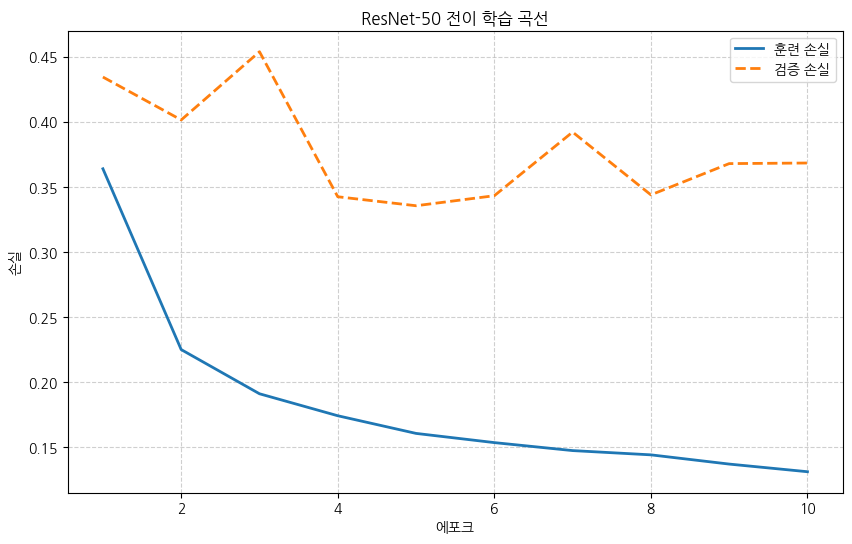

전이 학습 후 분류 정확도: 78.85%


In [11]:
# 참고 - 학습/검증 함수와 조기 종료 학습 루프 (정확도 포함)
import torch.optim as optim
import copy

# 1 에포크 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 검증 함수(손실과 분류 정확도 반환)
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# 학습 환경 설정
EPOCHS = 20
PATIENCE = 5
LR = 1e-3
criterion = nn.CrossEntropyLoss()

# 특징 추출 방식: requires_grad=True 인 fc 파라미터만 최적화
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=LR,
)

# 학습 루프
# 학습 로거 설정
log = common.EpochLogger(EPOCHS)
# 조기 종료 판정을 위한 변수 초기화
best_valid_loss = float('inf')
best_model_params, best_epoch, patience_counter = None, 0, 0
best_epoch = -1
for epoch in range(1, EPOCHS + 1):
    # 최적화
    train_loss = train_epoch(
        model, train_loader, criterion, optimizer, device,
    )
    # 검증
    valid_loss, valid_acc = evaluate(
        model, valid_loader, criterion, device,
    )
    # 학습 로그 저장 및 출력
    log.row(epoch, train_loss, valid_loss, valid_acc * 100)
    # 조기 종료 판단
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_params = copy.deepcopy(model.state_dict())
        best_epoch = epoch
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:            
            break
# 최적 모델로 복원
if best_model_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 모델 복원')
        model.load_state_dict(best_model_params)
# 학습 곡선 시각화
log.plot(title='ResNet-50 전이 학습 곡선')

# 전이 학습 후 분류 정확도
accuracy_after = get_accuracy(model, test_loader, device)
print(f'전이 학습 후 분류 정확도: {accuracy_after * 100:.2f}%')

- 본문에서는 5 에포크 만에 최저 검증 손실에 도달하고, 최적 에포크 모델의 분류 정확도가 78.69%로 전이 학습 전에 비해 약 19%p 올랐다.
    - 사전 학습된 ResNet-50으로 흉부 X선 사진을 분류할 수 있음을 보여 주는 결과다.
- 다만 80% 안팎의 정확도에 만족하기는 어렵다. 성능이 낮은 이유는 여러 가지다.
    - 미세 조정이 아닌 특징 추출 방식을 사용했다.
    - 컬러 이미지로 학습한 ResNet-50을 회색조 흉부 X선 사진으로 전이 학습했다.

## 정리

- 허깅페이스 허브는 수많은 공개 사전 학습 모델을 모아 둔 플랫폼이며, 비전 모델은 timm 라이브러리로 손쉽게 내려받아 사용할 수 있다.
- timm은 모델뿐 아니라 모델 설정에 맞는 데이터 변환 객체(`resolve_data_config()`, `create_transform()`)도 함께 제공한다.
- 사전 학습 모델을 전이 학습에 사용하려면 새로운 목적에 맞게 출력층을 교체해야 한다.
    - 특징 추출 방식에서는 교체 전에 모든 파라미터를 고정해야 새로 추가한 계층만 학습 대상으로 남는다.
- `ImageFolder`는 클래스별 디렉터리 구조를 그대로 데이터셋으로 만들어 준다.